# Portfolio Optimization Methods with PyPortfolioOpt — S&P 500 Universe

In [1]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns, objective_functions, HRPOpt
from pypfopt.black_litterman import BlackLittermanModel, market_implied_prior_returns
from scipy.optimize import minimize
DATA = 'notebook_data'
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

## Data: full S&P 500, 3y daily, FRED T-bill (cached; re-run fetch_sp500_all.py to refresh)

In [2]:
cons = pd.read_csv(f'{DATA}/sp500_constituents.csv', index_col='Symbol')
px   = pd.read_csv(f'{DATA}/sp500_prices_3y.csv', index_col=0, parse_dates=True)
vol  = pd.read_csv(f'{DATA}/sp500_volume_3y.csv', index_col=0, parse_dates=True)
px   = px.loc[:, px.isna().sum() < 20].ffill().dropna()     # drop thin/incomplete tickers (spinoffs etc.)
vol  = vol.reindex(columns=px.columns, index=px.index)
rf_hist = pd.read_csv(f'{DATA}/tbill_3mo_fred.csv', index_col=0, parse_dates=True).iloc[:, 0].dropna()
RF = rf_hist.iloc[-1] / 100
print(f'{px.shape[1]} tickers x {px.shape[0]} days  |  RF (3mo T-bill) = {RF:.2%} as of {rf_hist.index[-1].date()}')

496 tickers x 752 days  |  RF (3mo T-bill) = 3.84% as of 2026-07-14


## Full-universe sanity check (all ~500 names, Max-Sharpe scales fine)

In [3]:
mu_full = expected_returns.mean_historical_return(px)
S_full  = risk_models.sample_cov(px)
ef_full = EfficientFrontier(mu_full, S_full, weight_bounds=(0, 0.05))
ef_full.max_sharpe(risk_free_rate=RF)
w_full = pd.Series(ef_full.clean_weights())
r, v, sr = ef_full.portfolio_performance(risk_free_rate=RF)
print(f'Full 500-name Max-Sharpe: return {r:.1%}  vol {v:.1%}  Sharpe {sr:.2f}')
print(w_full[w_full > 0].sort_values(ascending=False).head(10).mul(100).round(1))

Full 500-name Max-Sharpe: return 57.9%  vol 12.9%  Sharpe 4.20
HWM     5.0
CME     5.0
WDC     5.0
T       5.0
STX     5.0
MO      5.0
JNJ     5.0
WELL    5.0
BNY     5.0
CASY    5.0
dtype: float64


## Demo universe: top-30 by dollar volume (legible charts; same calls work on all 500 above)

In [4]:
dollar_vol = (px * vol).mean()
UNIV    = dollar_vol.sort_values(ascending=False).head(30).index.tolist()
prices  = px[UNIV]
sectors = cons.loc[UNIV, 'GICS Sector']
mu    = expected_returns.mean_historical_return(prices)
S     = risk_models.sample_cov(prices)
S_lw  = risk_models.CovarianceShrinkage(prices).ledoit_wolf()

def to_series(w): return pd.Series(dict(w)).reindex(UNIV).fillna(0)
def metrics(w):                                     # evaluate every method under one consistent cov (S_lw)
    r = float(w @ mu); v = float(np.sqrt(w @ S_lw @ w)); return r, v, (r - RF) / v
print('Universe:', UNIV)

Universe: ['NVDA', 'TSLA', 'AAPL', 'MSFT', 'AMZN', 'META', 'AMD', 'MU', 'GOOGL', 'AVGO', 'PLTR', 'GOOG', 'INTC', 'NFLX', 'SMCI', 'LLY', 'UNH', 'ORCL', 'COIN', 'JPM', 'V', 'XOM', 'MRVL', 'BRK-B', 'CRM', 'COST', 'WMT', 'HOOD', 'APP', 'AMAT']


## Methods

In [5]:
# 1/N (naive diversification)
w_eq = pd.Series(1 / len(UNIV), index=UNIV)

In [6]:
# Global minimum variance
ef = EfficientFrontier(mu, S, weight_bounds=(0, 0.15)); ef.min_volatility()
w_mv = to_series(ef.clean_weights())

In [7]:
# Markowitz max-Sharpe, sample covariance
ef = EfficientFrontier(mu, S, weight_bounds=(0, 0.15)); ef.max_sharpe(risk_free_rate=RF)
w_mk = to_series(ef.clean_weights())

In [8]:
# Markowitz max-Sharpe with Ledoit-Wolf shrinkage covariance
ef = EfficientFrontier(mu, S_lw, weight_bounds=(0, 0.15)); ef.max_sharpe(risk_free_rate=RF)
w_lw = to_series(ef.clean_weights())

In [9]:
# Robust MVO: Ledoit-Wolf covariance + L2 regularisation, de-concentrating the min-variance corner solution
# (L2 + max_sharpe together trigger a pypfopt warning due to its internal reformulation; min_volatility is the
# documented, warning-free combination)
ef = EfficientFrontier(mu, S_lw, weight_bounds=(0, 0.15))
ef.add_objective(objective_functions.L2_reg, gamma=0.15); ef.min_volatility()
w_l2 = to_series(ef.clean_weights())

In [10]:
# Equal Risk Contribution / Risk Parity (not built into pypfopt, solved directly)
Sig, n = S_lw.values, len(UNIV)
def erc_obj(w):
    pv = np.sqrt(w @ Sig @ w); trc = w * (Sig @ w) / pv
    return np.sum((trc - pv / n) ** 2)
res = minimize(erc_obj, np.ones(n) / n, method='SLSQP', bounds=[(0.001, 1)] * n,
               constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}], options={'ftol': 1e-14, 'maxiter': 1000})
w_erc = pd.Series(res.x / res.x.sum(), index=UNIV)

In [11]:
# ESG-constrained: illustrative sector-based ESG scores (no free live S&P-500-wide ESG feed), min average score 65
rng = np.random.default_rng(7)
sector_base = {s: rng.uniform(40, 80) for s in sectors.unique()}
esg = (sectors.map(sector_base) + rng.normal(0, 5, len(UNIV))).clip(0, 100)
ef = EfficientFrontier(mu, S_lw, weight_bounds=(0, 0.15))
ef.add_constraint(lambda w: esg.values @ w >= 65)
ef.max_sharpe(risk_free_rate=RF)
w_esg = to_series(ef.clean_weights())

In [12]:
# Black-Litterman: dollar-volume as a market-cap proxy (no free live cap feed for 500 names) + 2 illustrative views
mcaps = dollar_vol[UNIV]
pi = market_implied_prior_returns(mcaps, 2.5, S_lw, risk_free_rate=RF)
views = {UNIV[0]: pi[UNIV[0]] + 0.05, UNIV[1]: pi[UNIV[1]] - 0.03}   # bullish on #1, bearish on #2 by $ volume
bl = BlackLittermanModel(S_lw, pi=pi, absolute_views=views)
mu_bl = bl.bl_returns()
ef = EfficientFrontier(mu_bl, S_lw, weight_bounds=(0, 0.15)); ef.max_sharpe(risk_free_rate=RF)
w_bl = to_series(ef.clean_weights())

In [13]:
# Hierarchical Risk Parity (correlation clustering, no covariance inversion)
hrp = HRPOpt(prices.pct_change().dropna()); hrp.optimize()
w_hrp = to_series(hrp.clean_weights())

## Efficient frontier (Markowitz, Ledoit-Wolf covariance)

In [14]:
methods = {'1/N': w_eq, 'Min-Var': w_mv, 'Markowitz': w_mk, 'Markowitz+LW': w_lw, 'Robust (L2+LW)': w_l2,
          'ERC (Risk Parity)': w_erc, 'ESG-constrained': w_esg, 'Black-Litterman': w_bl, 'HRP': w_hrp}

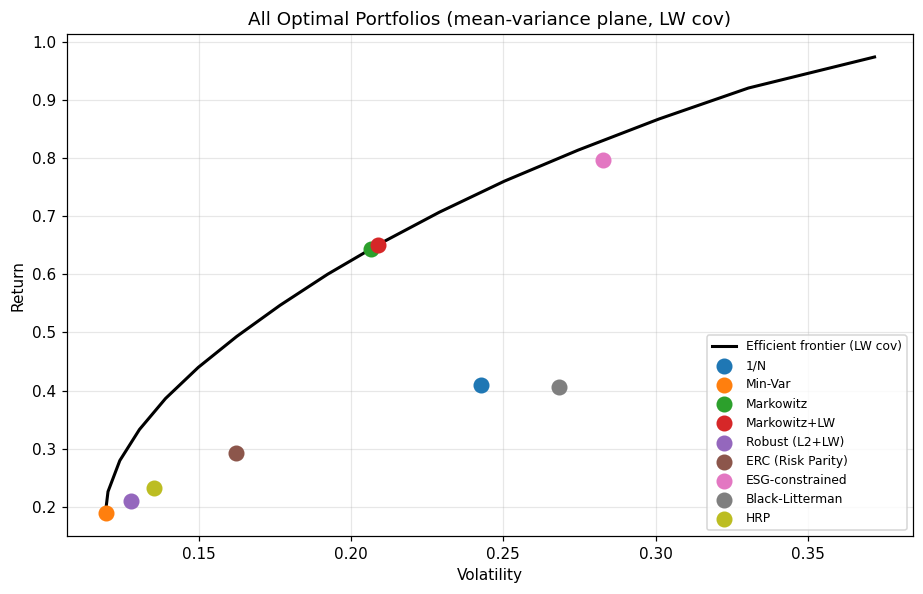

In [15]:
frontier = []
for target in np.linspace(mu.min(), mu.max() * 0.95, 30):
    try:
        ef_t = EfficientFrontier(mu, S_lw, weight_bounds=(0, 0.15)); ef_t.efficient_return(target)
        frontier.append(ef_t.portfolio_performance(risk_free_rate=RF)[:2])
    except Exception:
        pass

plt.figure(figsize=(8.5, 5.5))
plt.plot(*zip(*[(v, r) for r, v in frontier]), lw=2, color='black', label='Efficient frontier (LW cov)')
cmap = plt.cm.tab10.colors
for i, (name, w) in enumerate(methods.items()):
    r, v, _ = metrics(w)
    plt.scatter(v, r, s=90, color=cmap[i % 10], zorder=5, label=name)
plt.xlabel('Volatility'); plt.ylabel('Return'); plt.title('All Optimal Portfolios (mean-variance plane, LW cov)')
plt.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

## Comparison

In [16]:
summary = pd.DataFrame({k: metrics(v) for k, v in methods.items()}, index=['Return', 'Vol', 'Sharpe']).T
summary['HHI'] = {k: float((w ** 2).sum()) for k, w in methods.items()}.values()   # concentration, lower = more diversified
summary[['Return', 'Vol']] = (summary[['Return', 'Vol']] * 100).round(2)
summary['Sharpe'] = summary['Sharpe'].round(3); summary['HHI'] = summary['HHI'].round(3)
summary.sort_values('Sharpe', ascending=False)

,Return,Vol,Sharpe,HHI
Markowitz+LW,65.02,20.87,2.932,0.123
Markowitz,64.38,20.66,2.930,0.128
ESG-constrained,79.67,28.28,2.682,0.122
ERC (Risk Parity),29.34,16.22,1.572,0.048
1/N,40.91,24.26,1.528,0.033
HRP,23.25,13.54,1.434,0.071
Black-Litterman,40.57,26.84,1.369,0.063
Robust (L2+LW),21.08,12.77,1.350,0.068
Min-Var,18.89,11.95,1.259,0.111


*Sharpe ratios here are unusually high because expected return is the in-sample historical mean over 2023-2026, an exceptional AI-stock bull run concentrated in exactly the top-dollar-volume names in this universe (Michaud's "error maximiser" critique from Session 9); do not expect these to hold out of sample.*

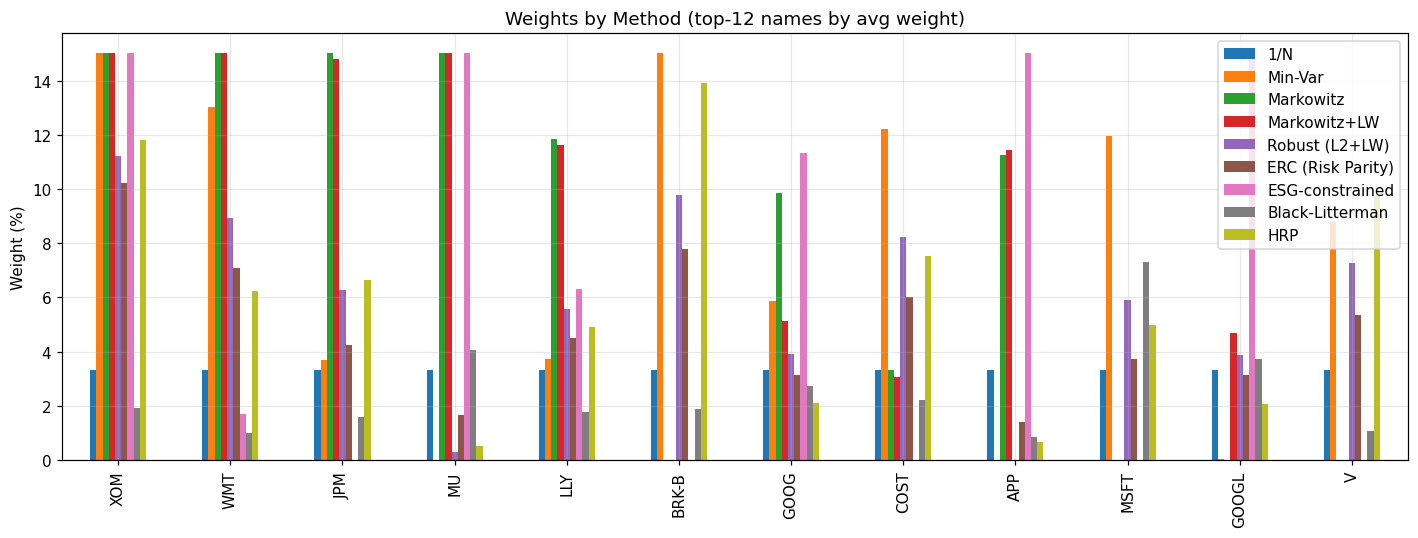

In [17]:
top = pd.concat(methods.values(), axis=1).set_axis(methods.keys(), axis=1).mean(axis=1).nlargest(12).index
w_df = pd.DataFrame({k: v[top] for k, v in methods.items()}) * 100
ax = w_df.plot(kind='bar', figsize=(13, 5))
ax.set_ylabel('Weight (%)'); ax.set_title('Weights by Method (top-12 names by avg weight)'); plt.tight_layout(); plt.show()

## How each method is different (novice explanation)

Every method needs two inputs: **expected return** for each stock (usually just its historical
average) and a **covariance matrix** (how every stock's moves relate to every other stock's moves,
which is what captures diversification). The methods below differ mainly in *how much they trust
these inputs* and *what they optimize for*.

**1/N (equal weight)** - the "don't bother optimizing" baseline. Splits money equally across every
stock, using no return or risk data at all. It exists as a sanity check: if a fancy method can't
beat this, the fancy method isn't earning its complexity.

**Min-Variance** - "I don't trust the return forecasts at all." Ignores expected returns entirely
and asks only: of all the ways to combine these stocks, which combination has the lowest possible
volatility? Reasonable when you trust your risk estimate but not your return forecast.

**Markowitz (Max-Sharpe)** - "give me the best return per unit of risk." The classic 1952 idea: use
both expected returns and the covariance matrix to find the one portfolio that maximizes the Sharpe
ratio. It sits exactly on the efficient frontier, but it is also the most sensitive to errors in the
return forecasts you feed it.

**Markowitz + Ledoit-Wolf (LW)** - same goal, better risk estimate. Identical math to plain
Markowitz, but the covariance matrix is shrunk first, since raw historical covariance from a limited
sample is noisy. Same recipe, less noisy ingredient.

**Robust (L2 + LW)** - "stop putting all the money in 2-3 stocks." Unconstrained optimizers often
concentrate huge weight in a handful of names because the math found a razor-thin edge there. This
adds a penalty (L2 regularisation) that punishes concentrated weights, spreading the solution out
without changing its risk level.

**ERC / Risk Parity** - "equal risk, not equal money." A different definition of balanced: finds
weights so every stock contributes the same share of total portfolio risk, rather than the same
share of capital. A volatile stock gets a smaller dollar weight so its risk contribution matches a
calmer stock's.

**ESG-constrained** - "same as Markowitz, but with a rule." The max-Sharpe optimizer again, with one
added rule: the portfolio's average ESG score must clear a minimum floor. Best possible Sharpe ratio
*subject to* that constraint.

**Black-Litterman** - "fix the biggest weakness of Markowitz: the inputs." Instead of forecasting
every stock's return yourself, it starts from a neutral, market-implied consensus return, then lets
you nudge it with a small number of specific views you are actually confident about. The optimizer
blends your views with the market consensus, weighted by your stated confidence.

**HRP (Hierarchical Risk Parity)** - a different mechanism entirely. Every method above (except
1/N) needs to invert the covariance matrix, which becomes unstable with many assets or noisy data.
HRP groups stocks into a tree by correlation (tech together, bonds together, etc.) and allocates
risk top-down through that tree, never inverting the full matrix - which is why it stays stable at
large scale.

### What's actually different

| Method | What it optimizes for | Uses return forecasts? | Inverts the covariance matrix? |
|---|---|---|---|
| 1/N | Nothing - just equal split | No | No |
| Min-Var | Lowest possible risk | No | Yes |
| Markowitz / +LW | Best return-per-risk (Sharpe) | Yes (raw historical) | Yes |
| Robust (L2+LW) | Low risk, less concentrated | No | Yes |
| ERC | Equal risk contribution per asset | No | Yes |
| ESG-constrained | Best Sharpe, with an ESG floor | Yes (raw historical) | Yes |
| Black-Litterman | Best Sharpe, on blended forecasts | Yes (market + your views) | Yes |
| HRP | Risk allocated via clustering | No | No |